# Basic Clustering with K-means

This notebook introduces the fundamental concepts of clustering using the K-means algorithm, one of the most popular unsupervised machine learning techniques. We will explore the algorithm's implementation, visualization techniques, and practical applications.

## 1. Import Required Libraries

First, let's import all the necessary libraries for data manipulation, visualization, and implementing the K-means algorithm:

In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# For reproducibility
np.random.seed(42)

# Display plots inline
%matplotlib inline

## 2. Understanding K-means Algorithm

K-means is a centroid-based clustering algorithm that partitions data into K distinct, non-overlapping clusters. The main goal is to minimize the sum of squared distances between data points and their assigned cluster centers.

### Algorithm Steps:

1. **Initialization**: Randomly select K data points as initial centroids
2. **Assignment**: Assign each data point to the nearest centroid
3. **Update**: Recalculate centroids as the mean of all points in each cluster
4. **Repeat**: Iterate steps 2-3 until convergence (centroids stop changing significantly)

### Mathematical Formulation:

The K-means algorithm aims to minimize the objective function:

$$J = \sum_{j=1}^{k} \sum_{i=1}^{n} ||x_i^{(j)} - c_j||^2$$

Where:
- $J$ is the objective function to minimize
- $k$ is the number of clusters
- $n$ is the number of data points
- $x_i^{(j)}$ is the $i$-th data point belonging to the $j$-th cluster
- $c_j$ is the centroid of the $j$-th cluster

### Visual Explanation of K-means

Let's create a visual representation of how the K-means algorithm works step by step:

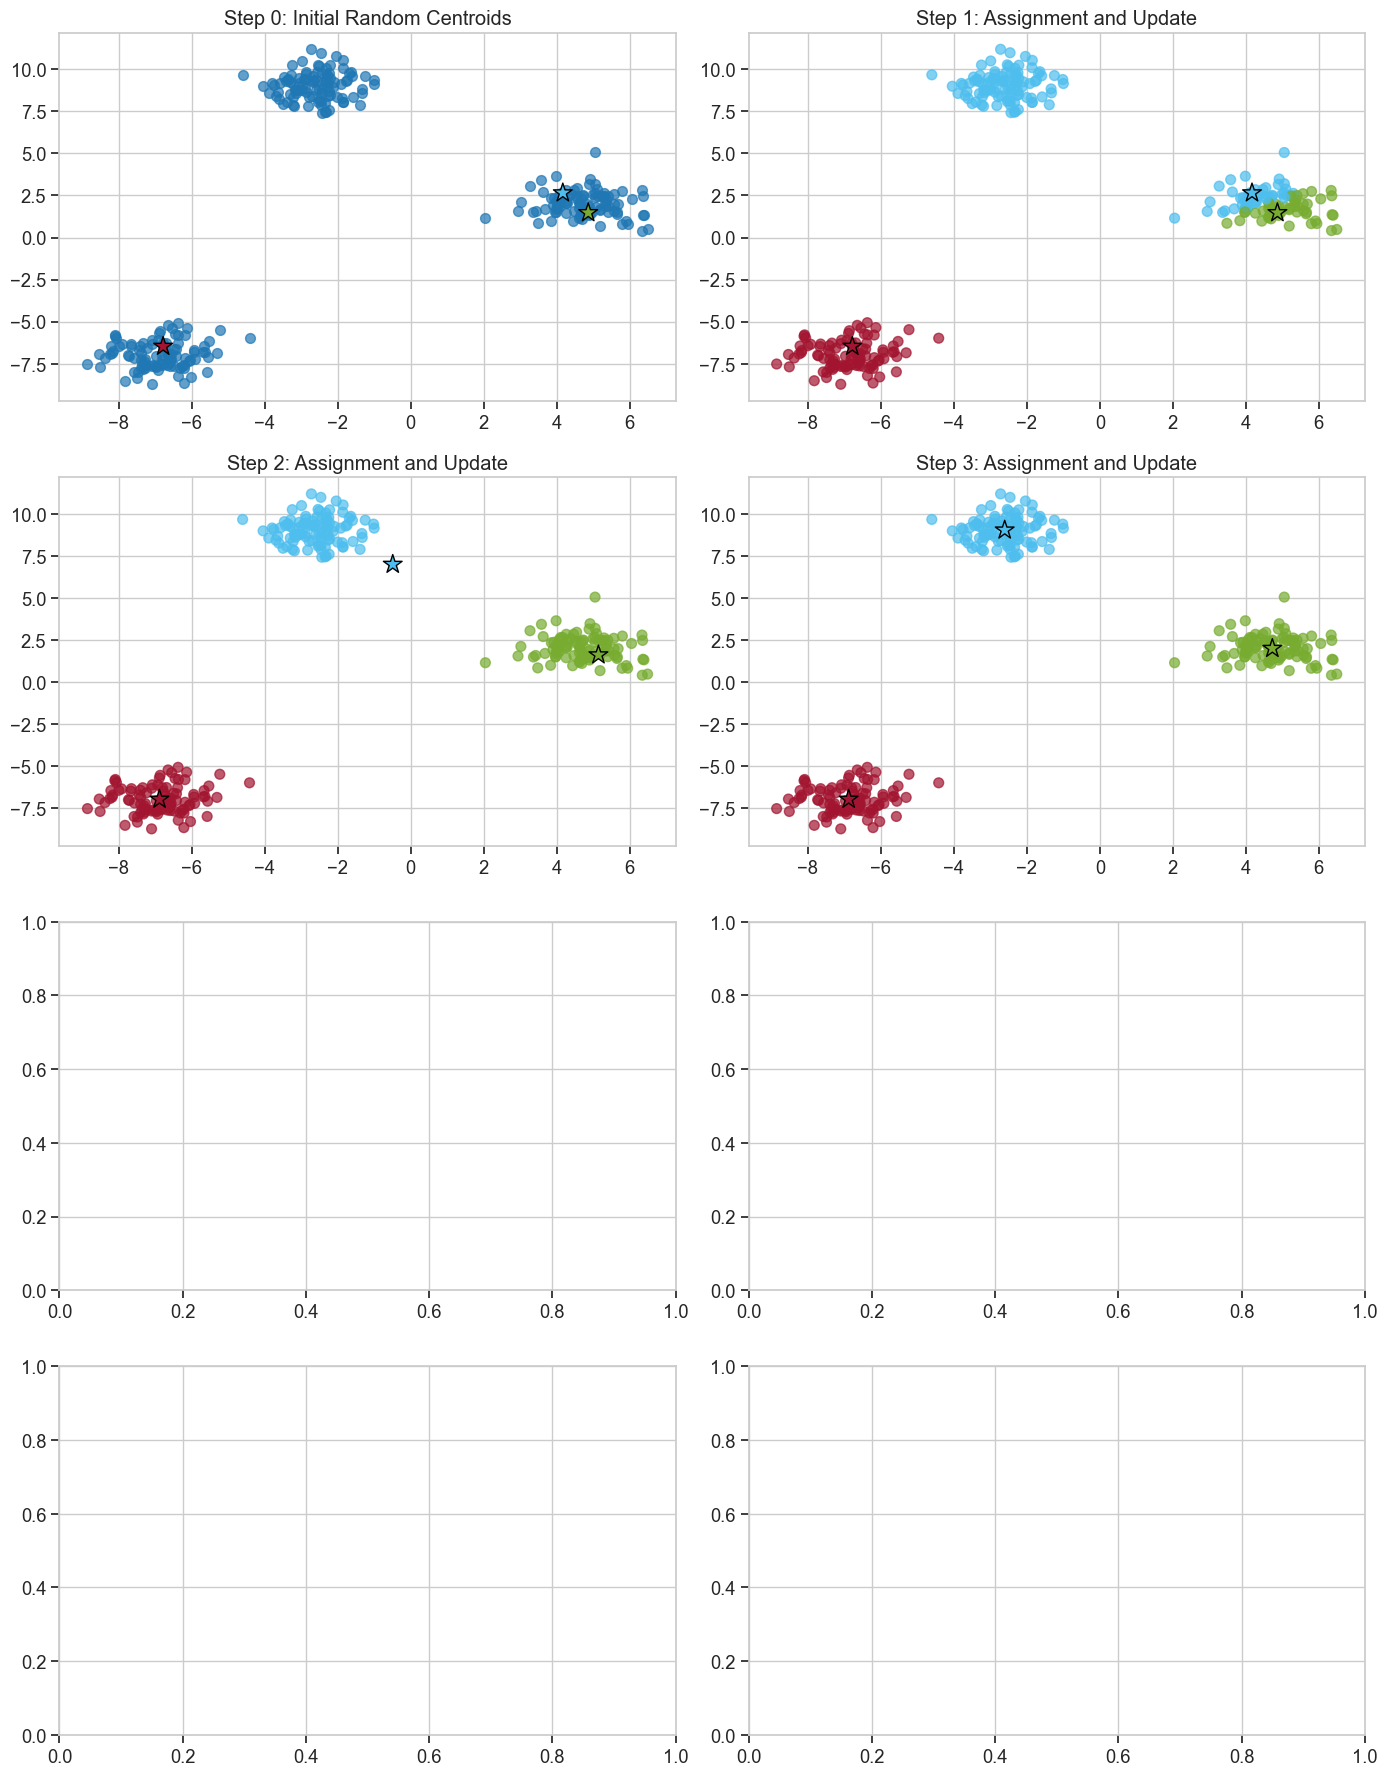

In [2]:
def plot_kmeans_steps(X, k=3, max_iterations=8):
    """
    Visualize the steps of the K-means algorithm
    """
    # Initialize centroids randomly
    np.random.seed(42)
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    axes = axes.flatten()
    
    # Color map for clusters
    colors = ['#4DBEEE', '#A2142F', '#77AC30', '#7E2F8E', '#EDB120', '#0072BD']
    
    # Initial plot with random centroids
    axes[0].scatter(X[:, 0], X[:, 1], s=50, alpha=0.7)
    axes[0].scatter(centroids[:, 0], centroids[:, 1], c=colors[:k], marker='*', s=200, edgecolor='k')
    axes[0].set_title('Step 0: Initial Random Centroids')
    
    for i in range(max_iterations):
        # Assign points to closest centroid
        distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        
        # Plot assignment step
        if i < 7:
            axes[i+1].scatter(X[:, 0], X[:, 1], c=[colors[label] for label in labels], s=50, alpha=0.7)
            axes[i+1].scatter(centroids[:, 0], centroids[:, 1], c=colors[:k], marker='*', s=200, edgecolor='k')
            axes[i+1].set_title(f'Step {i+1}: Assignment and Update')
        
        # Update centroids
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        
        # Check for convergence
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    plt.tight_layout()
    plt.show()

# Generate synthetic data for visualization
X, _ = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=0.8, random_state=42)

# Visualize K-means steps
plot_kmeans_steps(X, k=3)

## 3. Generating Synthetic Data

Before applying K-means to real-world data, let's experiment with synthetic datasets to better understand how the algorithm performs under different conditions.

We'll generate datasets with clear cluster structures using scikit-learn's `make_blobs` function.

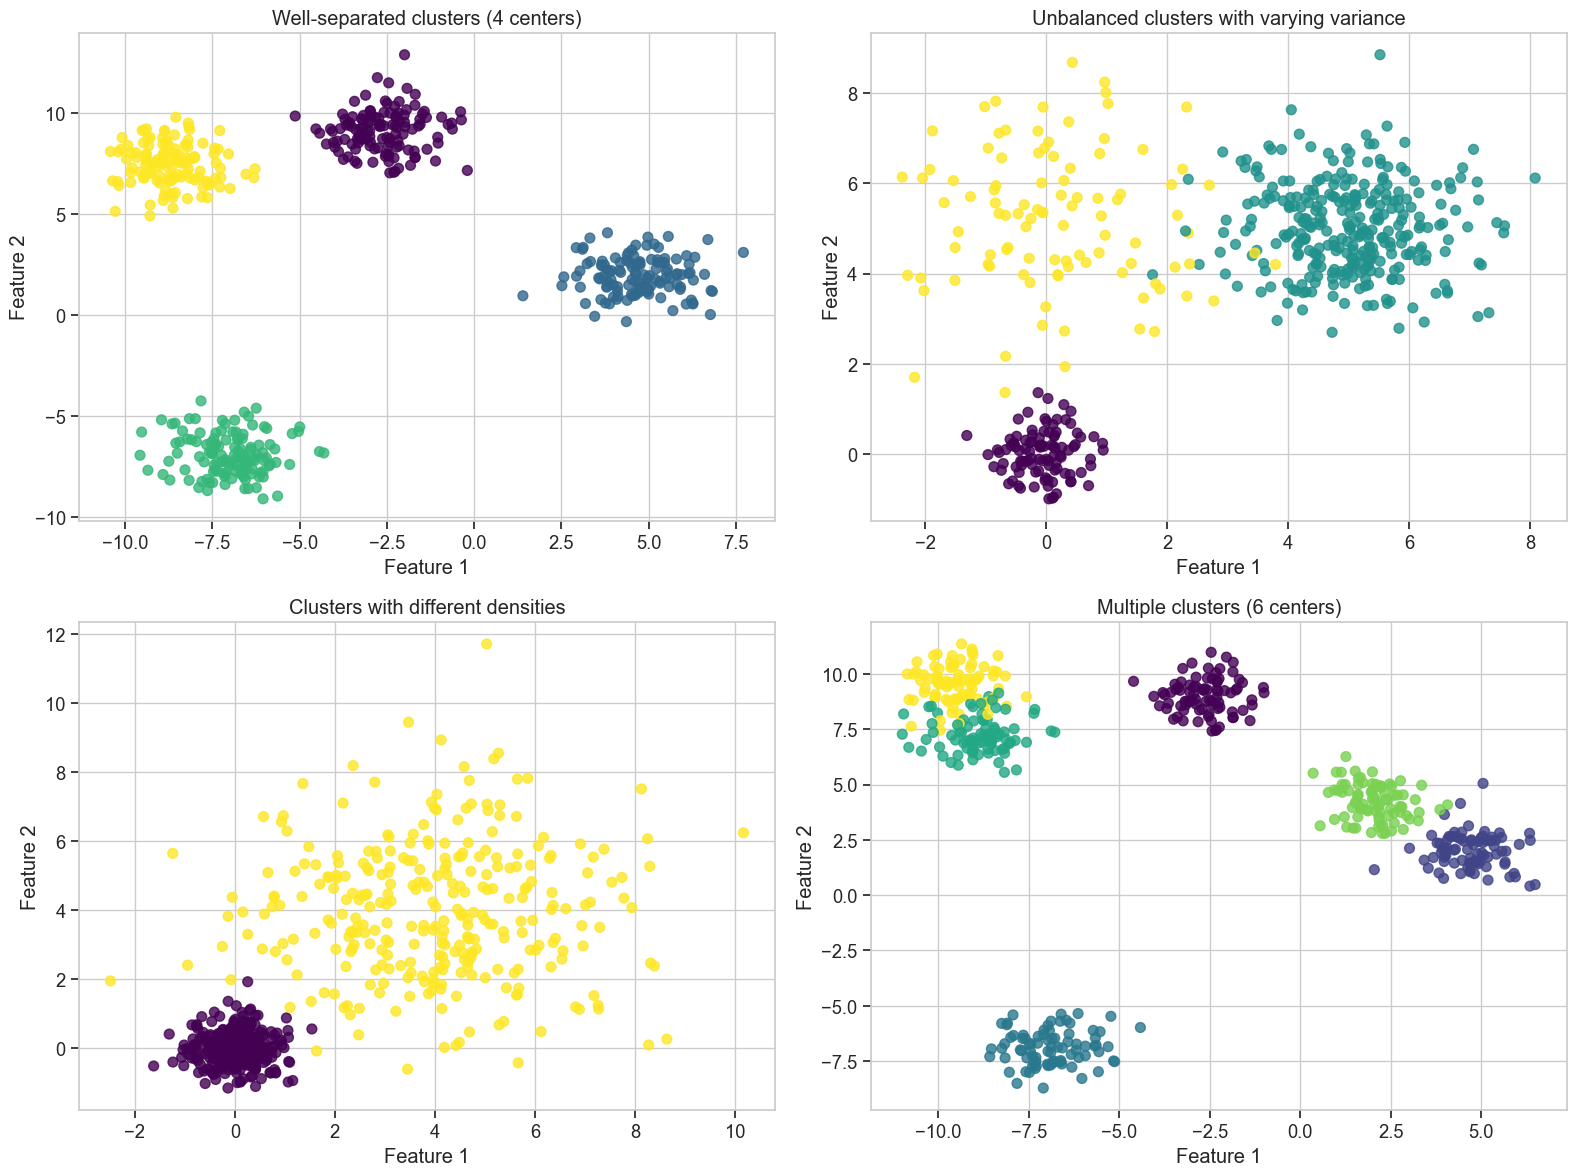

In [3]:
# Create synthetic datasets with various cluster configurations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Dataset 1: Well-separated clusters
X1, y1 = make_blobs(n_samples=500, centers=4, n_features=2, random_state=42)
axes[0, 0].scatter(X1[:, 0], X1[:, 1], c=y1, cmap='viridis', s=50, alpha=0.8)
axes[0, 0].set_title("Well-separated clusters (4 centers)")

# Dataset 2: Unbalanced clusters with different variances
X2, y2 = make_blobs(n_samples=[100, 300, 100], centers=[[0, 0], [5, 5], [0, 5]], 
                   cluster_std=[0.5, 1.0, 1.5], random_state=42)
axes[0, 1].scatter(X2[:, 0], X2[:, 1], c=y2, cmap='viridis', s=50, alpha=0.8)
axes[0, 1].set_title("Unbalanced clusters with varying variance")

# Dataset 3: Clusters with different densities
X3_1, y3_1 = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.5, random_state=42)
X3_2, y3_2 = make_blobs(n_samples=300, centers=[[4, 4]], cluster_std=2, random_state=42)
X3 = np.vstack([X3_1, X3_2])
y3 = np.hstack([y3_1, y3_2+1])
axes[1, 0].scatter(X3[:, 0], X3[:, 1], c=y3, cmap='viridis', s=50, alpha=0.8)
axes[1, 0].set_title("Clusters with different densities")

# Dataset 4: Many clusters
X4, y4 = make_blobs(n_samples=500, centers=6, n_features=2, cluster_std=0.8, random_state=42)
axes[1, 1].scatter(X4[:, 0], X4[:, 1], c=y4, cmap='viridis', s=50, alpha=0.8)
axes[1, 1].set_title("Multiple clusters (6 centers)")

for ax in axes.flatten():
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## 4. Implementing K-means from Scratch

To fully understand how K-means works, let's implement the algorithm from scratch. This implementation will follow the core steps of the algorithm and demonstrate each stage visually.

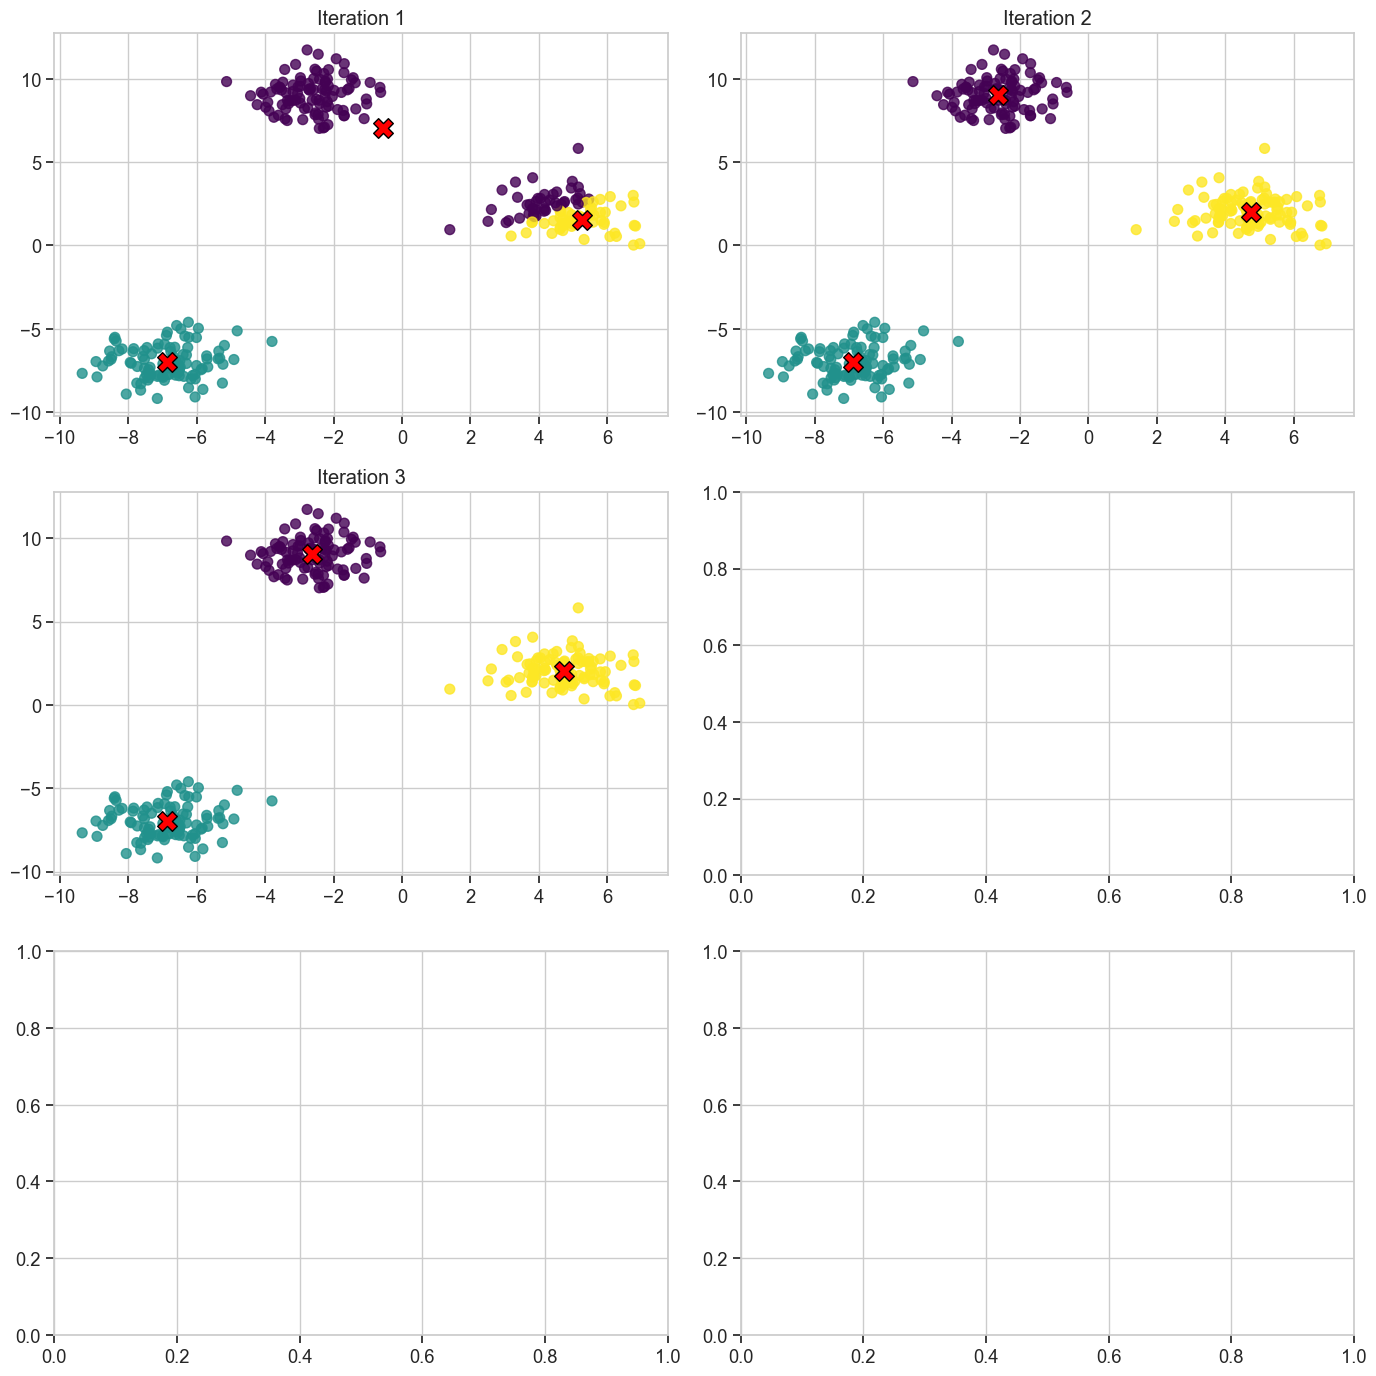

Final inertia: 566.86


In [4]:
class KMeansFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        
    def fit(self, X):
        """
        Fit K-means to the data
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        # Initialize centroids randomly
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx]
        
        # Initialize convergence tracker
        prev_centroids = np.zeros_like(self.centroids)
        
        # Initialize visualization objects
        fig, axes = plt.subplots(3, 2, figsize=(14, 14))
        axes = axes.flatten()
        
        for iteration in range(min(self.max_iters, 6)):  # Display up to 6 iterations
            # Assign each point to the nearest centroid
            distances = np.sqrt(((X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
            self.labels = np.argmin(distances, axis=1)
            
            # Store previous centroids
            prev_centroids = self.centroids.copy()
            
            # Update centroids
            for i in range(self.n_clusters):
                if sum(self.labels == i) > 0:  # Avoid empty clusters
                    self.centroids[i] = X[self.labels == i].mean(axis=0)
            
            # Visualize current iteration
            axes[iteration].scatter(X[:, 0], X[:, 1], c=self.labels, cmap='viridis', s=50, alpha=0.8)
            axes[iteration].scatter(self.centroids[:, 0], self.centroids[:, 1], c='red', marker='X', s=200, edgecolor='black')
            axes[iteration].set_title(f"Iteration {iteration+1}")
            
            # Check convergence
            if np.all(self.centroids == prev_centroids):
                break
                
        # Calculate inertia (sum of squared distances to nearest centroid)
        self.inertia_ = 0
        for i in range(self.n_clusters):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                self.inertia_ += np.sum((cluster_points - self.centroids[i])**2)
                
        plt.tight_layout()
        plt.show()
        
        return self
    
    def predict(self, X):
        """
        Predict the closest cluster for each sample in X
        """
        distances = np.sqrt(((X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
        return np.argmin(distances, axis=1)

# Use the well-separated dataset
X, _ = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Apply our custom K-means implementation
kmeans_custom = KMeansFromScratch(n_clusters=3, random_state=42)
kmeans_custom.fit(X)

print(f"Final inertia: {kmeans_custom.inertia_:.2f}")

## 5. Using scikit-learn's K-means Implementation

While implementing K-means from scratch helps understand the algorithm, in practice we typically use optimized library implementations. Let's use scikit-learn's `KMeans` class to perform clustering.

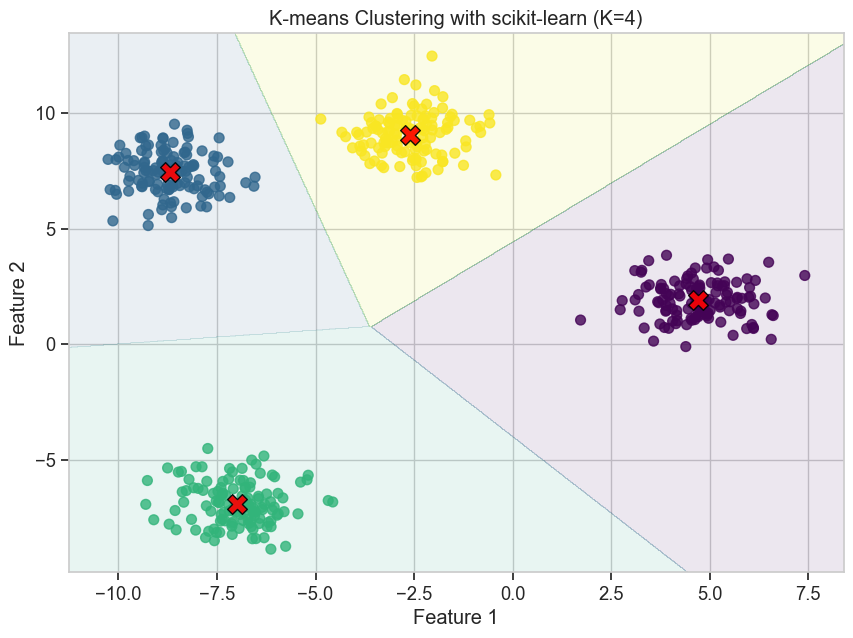

Inertia: 768.60
Number of iterations to converge: 2
Final cluster centers shape: (4, 2)


In [6]:
# Generate sample data
X, true_labels = make_blobs(n_samples=500, centers=4, cluster_std=0.9, random_state=42)

# Initialize and fit scikit-learn's KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Get cluster centers
centers = kmeans.cluster_centers_

# Plot the clustering result
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolor='black')

# Add decision boundaries (Voronoi diagram)
# Create a meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict cluster labels for each point in the meshgrid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.1, cmap='viridis')

plt.title('K-means Clustering with scikit-learn (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Display some key attributes and results
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Number of iterations to converge: {kmeans.n_iter_}")
print(f"Final cluster centers shape: {kmeans.cluster_centers_.shape}")

## 6. Selecting the Optimal Number of Clusters

One of the challenges in K-means clustering is determining the optimal number of clusters. Let's implement and visualize three common methods:

1. **Elbow Method**: Plot the inertia (sum of squared distances) for different values of K
2. **Silhouette Score**: Measure how similar points are to their own cluster compared to other clusters
3. **Gap Statistic**: Compare inertia with that of a reference null distribution

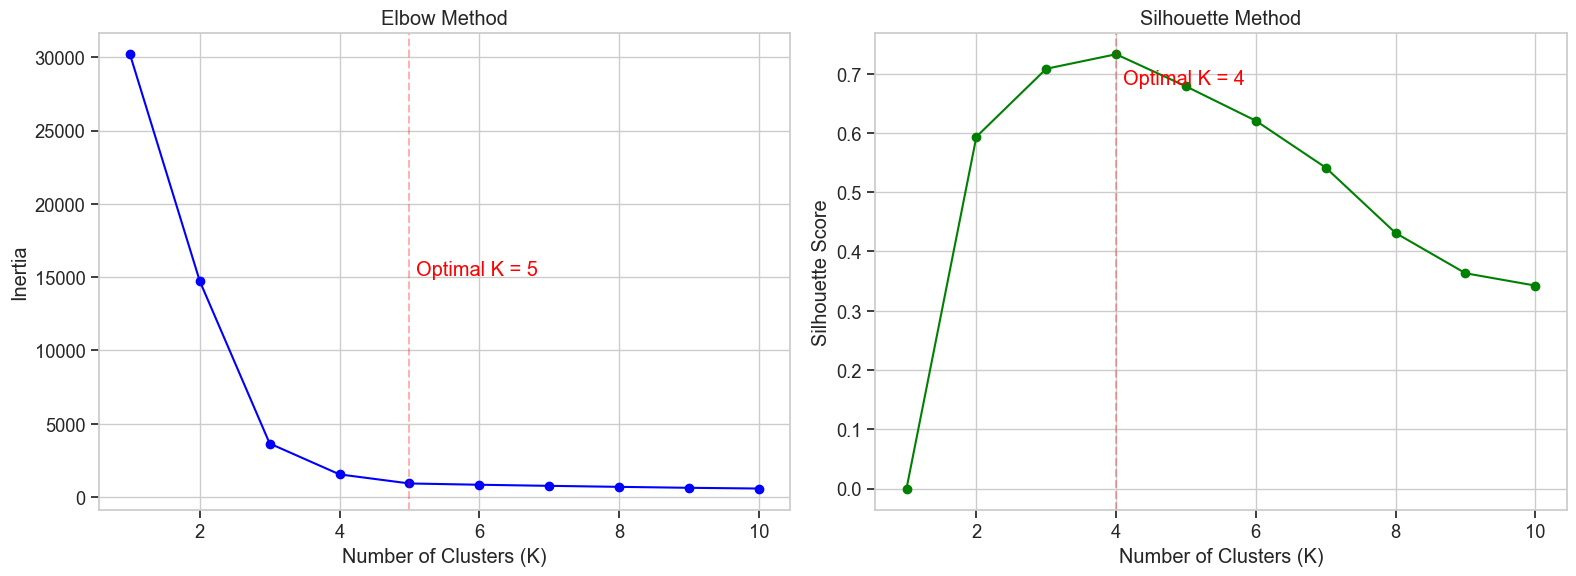

In [7]:
# Generate a dataset with 5 underlying clusters
X, true_labels = make_blobs(n_samples=500, centers=5, random_state=42)

# Function to calculate metrics for different K values
def calculate_metrics(X, max_k=10):
    k_range = range(1, max_k + 1)
    inertia_values = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia_values.append(kmeans.inertia_)
        
        # Silhouette score is not defined for k=1
        if k > 1:
            labels = kmeans.labels_
            silhouette_scores.append(silhouette_score(X, labels))
        else:
            silhouette_scores.append(0)
    
    return k_range, inertia_values, silhouette_scores

# Calculate metrics
k_range, inertia_values, silhouette_scores = calculate_metrics(X, max_k=10)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Elbow Method
ax1.plot(k_range, inertia_values, 'bo-')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

# Highlight the "elbow" (this is subjective, here we know it's 5)
ax1.axvline(x=5, color='r', linestyle='--', alpha=0.3)
ax1.text(5.1, inertia_values[0]/2, 'Optimal K = 5', color='r')

# Plot Silhouette Method
ax2.plot(k_range, silhouette_scores, 'go-')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Method')
ax2.grid(True)

# Highlight the maximum silhouette score
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 1
ax2.axvline(x=optimal_k, color='r', linestyle='--', alpha=0.3)
ax2.text(optimal_k + 0.1, max(silhouette_scores) - 0.05, f'Optimal K = {optimal_k}', color='r')

plt.tight_layout()
plt.show()

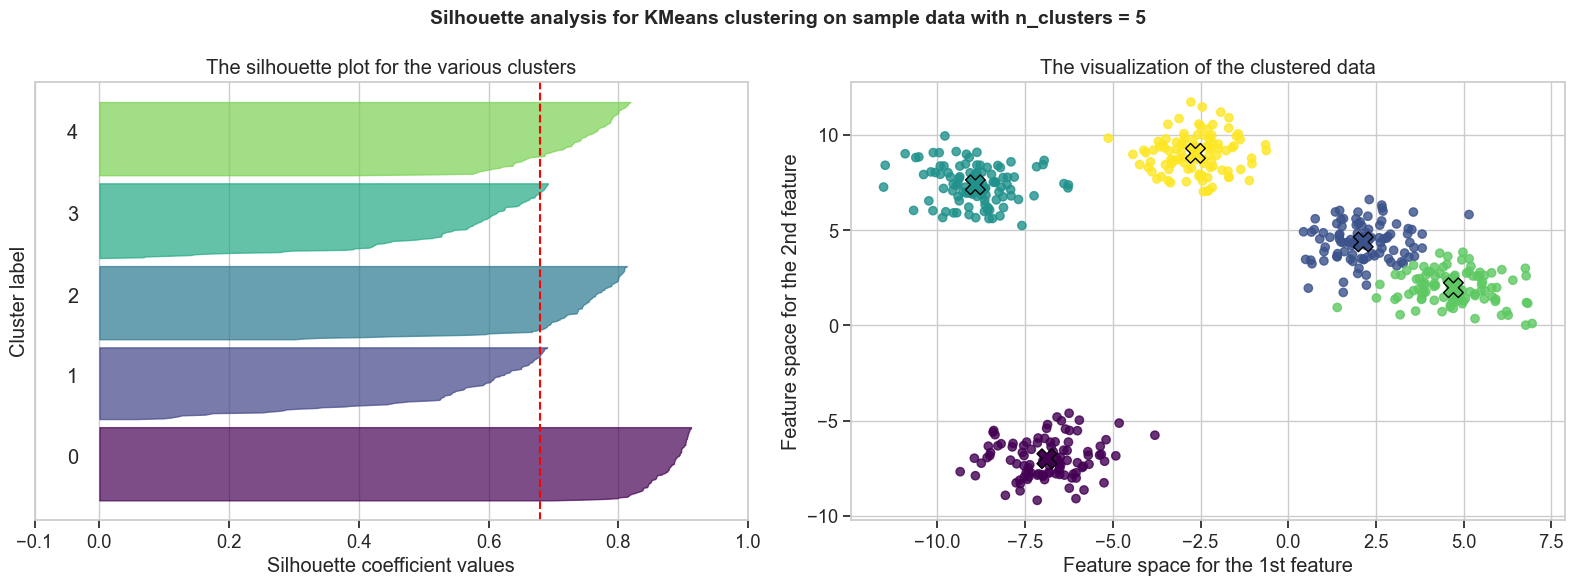

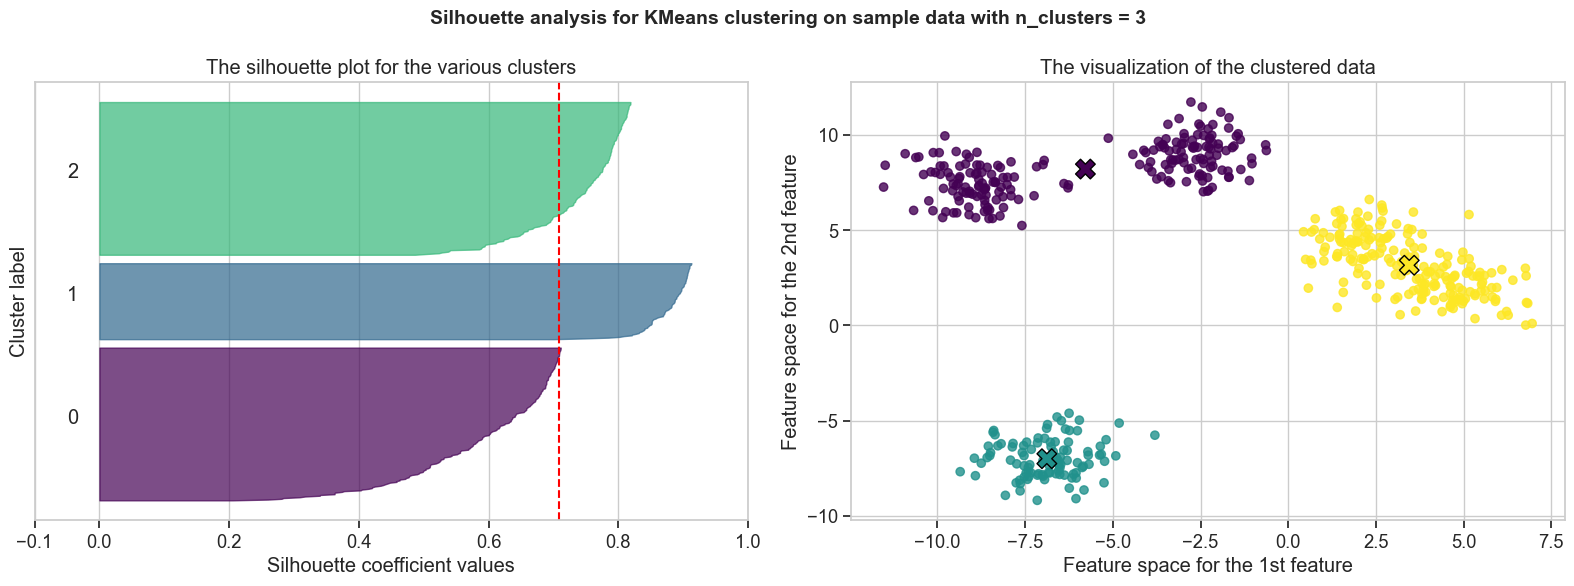

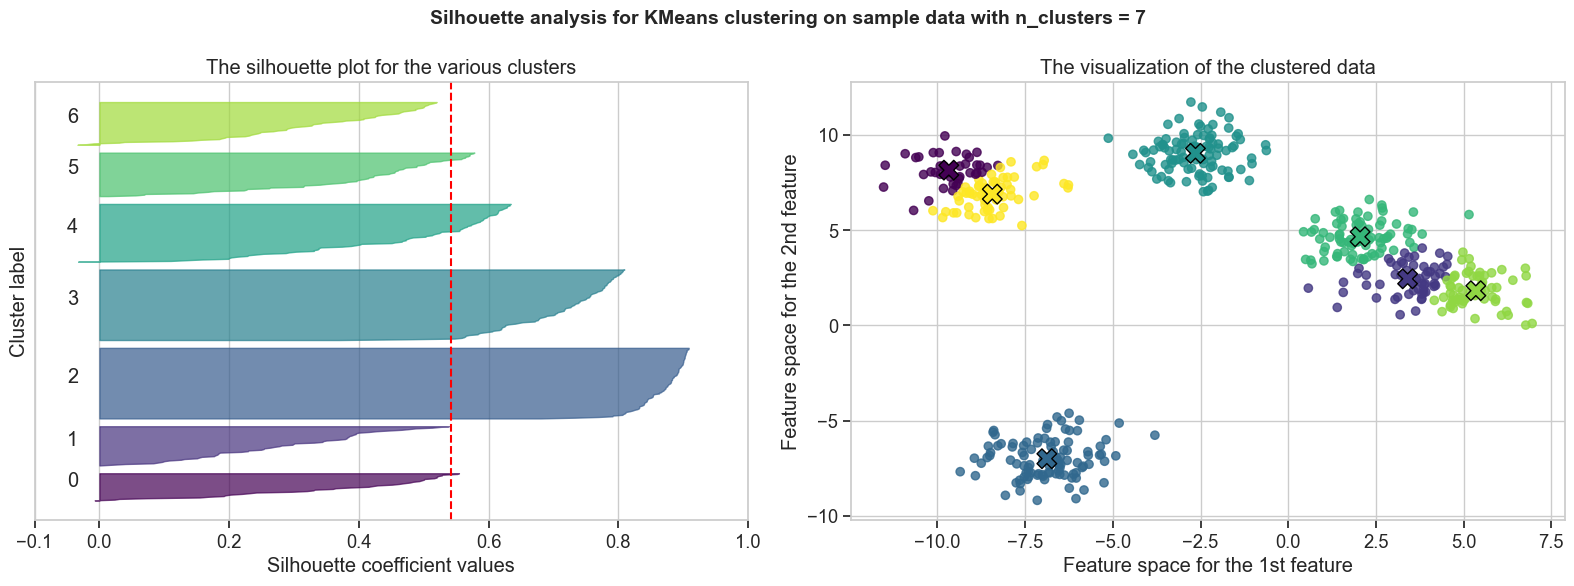

In [8]:
# Visualize Silhouette Analysis in more detail
from sklearn.metrics import silhouette_samples

def plot_silhouette_analysis(X, n_clusters):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Initialize KMeans and fit
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # Compute silhouette scores for each sample
    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate silhouette scores for samples in cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.viridis(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        # Label the silhouette plots with cluster numbers
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10
    
    ax1.set_title("The silhouette plot for the various clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    
    # The vertical line for average silhouette score
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    
    # Plot the clusters themselves
    centers = kmeans.cluster_centers_
    ax2.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.8)
    ax2.scatter(centers[:, 0], centers[:, 1], c=range(n_clusters), 
                marker='X', s=200, edgecolors='k', cmap='viridis')
    
    ax2.set_title("The visualization of the clustered data")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    
    plt.suptitle(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Analyze clusters with the true number (5) and with incorrect numbers
plot_silhouette_analysis(X, n_clusters=5)  # The correct number
plot_silhouette_analysis(X, n_clusters=3)  # Too few clusters
plot_silhouette_analysis(X, n_clusters=7)  # Too many clusters

## 7. Visualizing Clusters

Visualization is a critical part of understanding clustering results. Let's explore various techniques to visualize clusters effectively.

<Figure size 1200x1000 with 0 Axes>

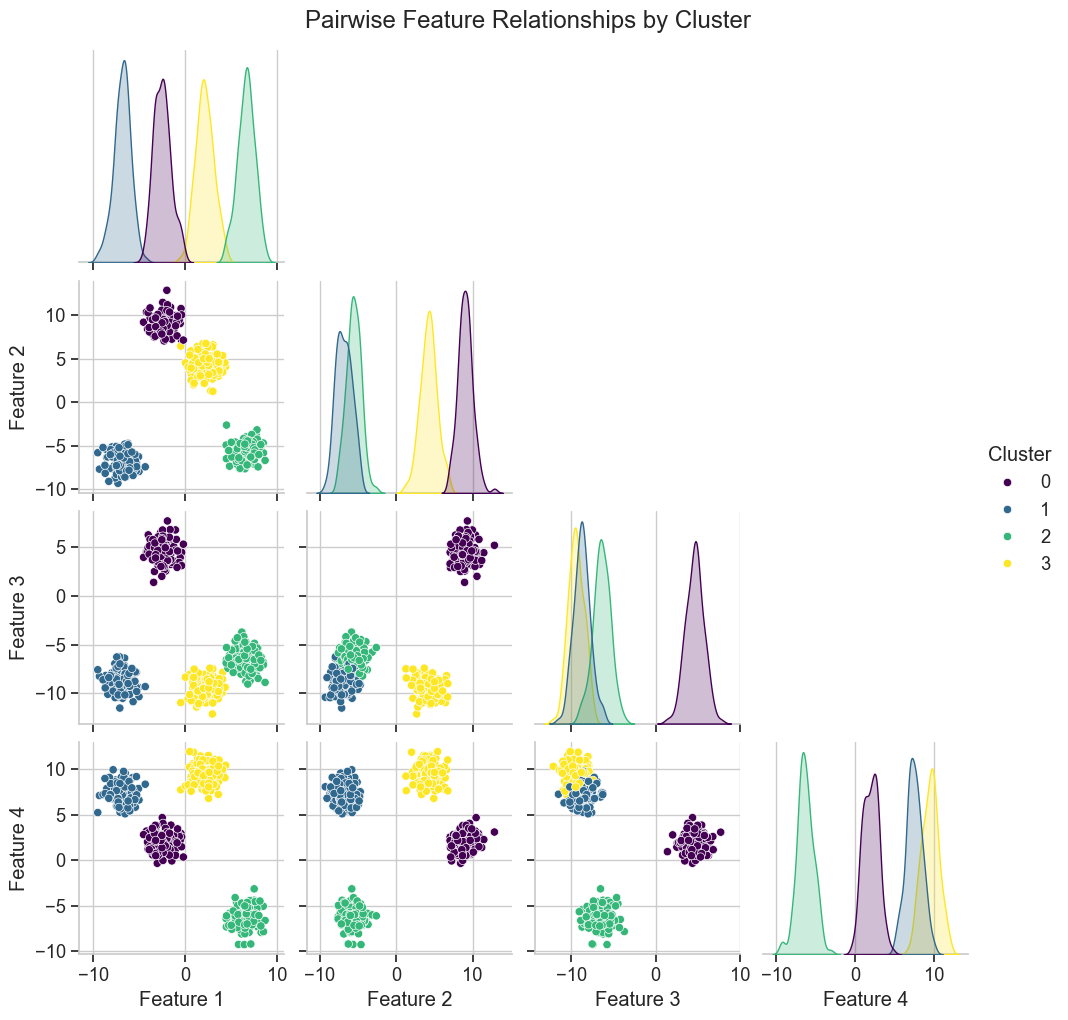

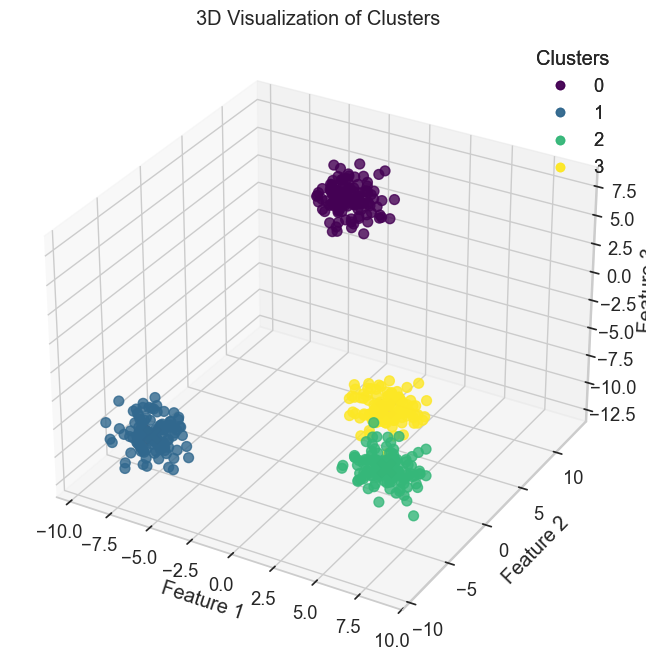

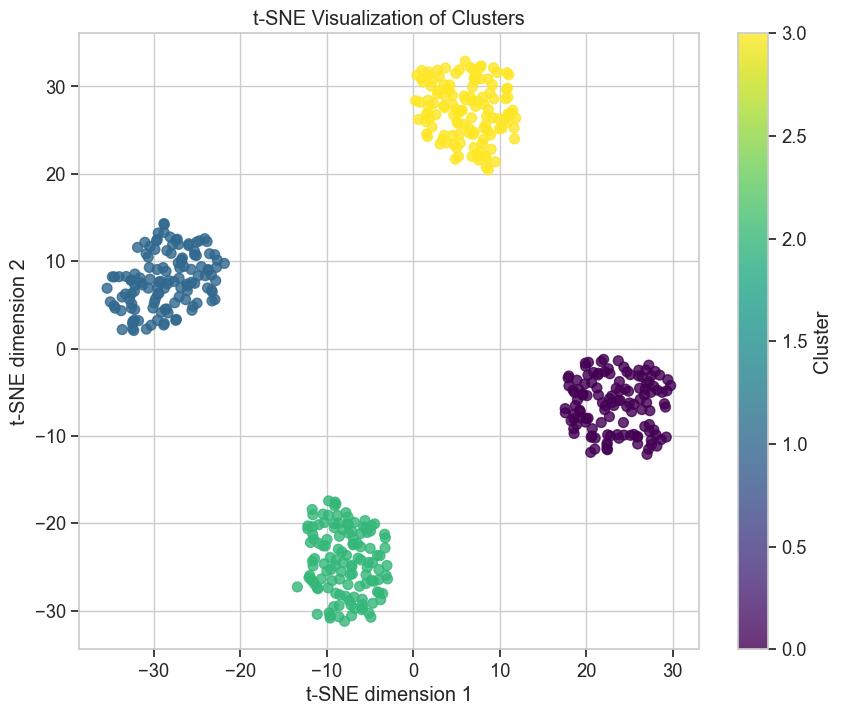

In [9]:
# Generate a dataset with 4 clusters and 4 features
X_multi, y_multi = make_blobs(n_samples=500, centers=4, n_features=4, random_state=42)

# Apply K-means
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_multi)

# Create a DataFrame for easier visualization
df = pd.DataFrame(X_multi, columns=[f'Feature {i+1}' for i in range(X_multi.shape[1])])
df['Cluster'] = labels

# 1. Scatter plot matrix using seaborn's pairplot
plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(df, hue='Cluster', palette='viridis', corner=True)
pair_plot.fig.suptitle('Pairwise Feature Relationships by Cluster', y=1.02)
plt.show()

# 2. 3D scatter plot for the first three features
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot points
scatter = ax.scatter(X_multi[:, 0], X_multi[:, 1], X_multi[:, 2], 
                     c=labels, cmap='viridis', s=50, alpha=0.8)

# Plot cluster centers
centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
           c='red', marker='X', s=200, edgecolor='black')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D Visualization of Clusters')
plt.show()

# 3. Using t-SNE to visualize high-dimensional clusters
from sklearn.manifold import TSNE

# Apply t-SNE to reduce dimensions to 2
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_multi)

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
plt.title('t-SNE Visualization of Clusters')
plt.colorbar(label='Cluster')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

## 8. Real-world Example: Customer Segmentation

Now let's apply K-means to a real-world problem: customer segmentation. This is a common application of clustering in business contexts.

We'll use a simplified customer dataset with features like age, income, spending score, etc.

In [10]:
# Create a synthetic customer dataset
np.random.seed(42)

# Sample size
n_samples = 200

# Generate age (18-70)
age = np.random.randint(18, 71, size=n_samples)

# Generate annual income ($10K - $100K)
income = np.random.randint(10, 101, size=n_samples) * 1000

# Generate spending score (1-100)
spending = np.random.randint(1, 101, size=n_samples)

# Generate number of purchases (0-50)
purchases = np.random.randint(0, 51, size=n_samples)

# Generate customer tenure in months (1-120)
tenure = np.random.randint(1, 121, size=n_samples)

# Create a DataFrame
customer_data = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Spending_Score': spending,
    'Purchases': purchases,
    'Tenure': tenure
})

# Display the first few rows
print("Customer Dataset Sample:")
customer_data.head()

Customer Dataset Sample:


,Age,Income,Spending_Score,Purchases,Tenure
0,56,71000,65,8,1
1,69,86000,8,6,51
2,46,12000,16,27,45
3,32,79000,14,13,77
4,60,81000,76,30,4


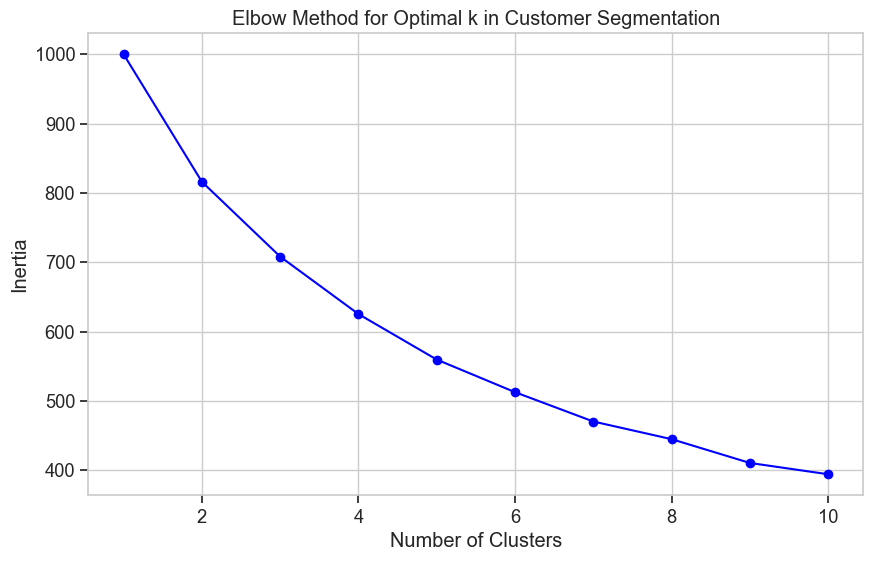

Cluster sizes:
Cluster
0    46
1    55
2    55
3    44
Name: count, dtype: int64


In [11]:
# Preprocess the data for clustering
X_customer = customer_data.values

# Scale the features
scaler = StandardScaler()
X_customer_scaled = scaler.fit_transform(X_customer)

# Find optimal number of clusters using the elbow method
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_customer_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k in Customer Segmentation')
plt.grid(True)
plt.show()

# Based on the elbow method, let's choose k=4
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(X_customer_scaled)

# Display cluster sizes
cluster_sizes = customer_data['Cluster'].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

Cluster Profiles:
               Age        Income  Spending_Score  Purchases     Tenure
Cluster                                                               
0        57.608696  72391.304348       37.304348  27.565217  62.978261
1        38.290909  35054.545455       25.581818  16.527273  50.727273
2        46.636364  36654.545455       78.490909  30.527273  87.618182
3        33.659091  68795.454545       65.909091  22.068182  30.272727


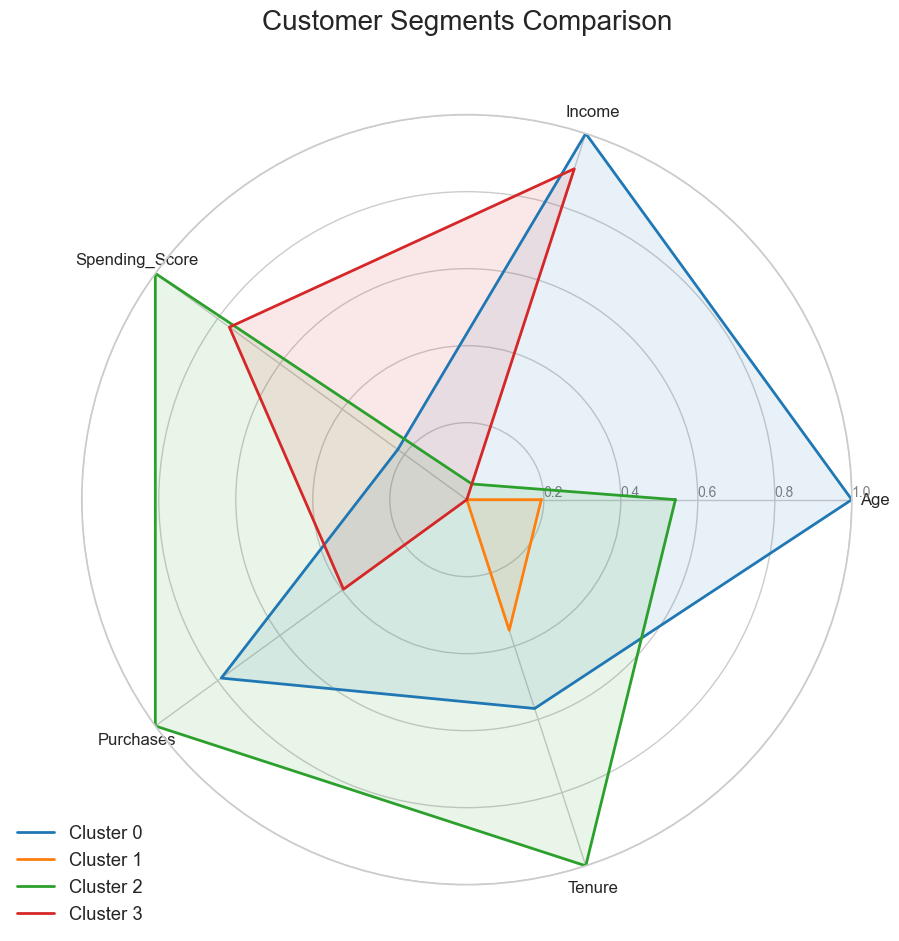

<Figure size 1500x1000 with 0 Axes>

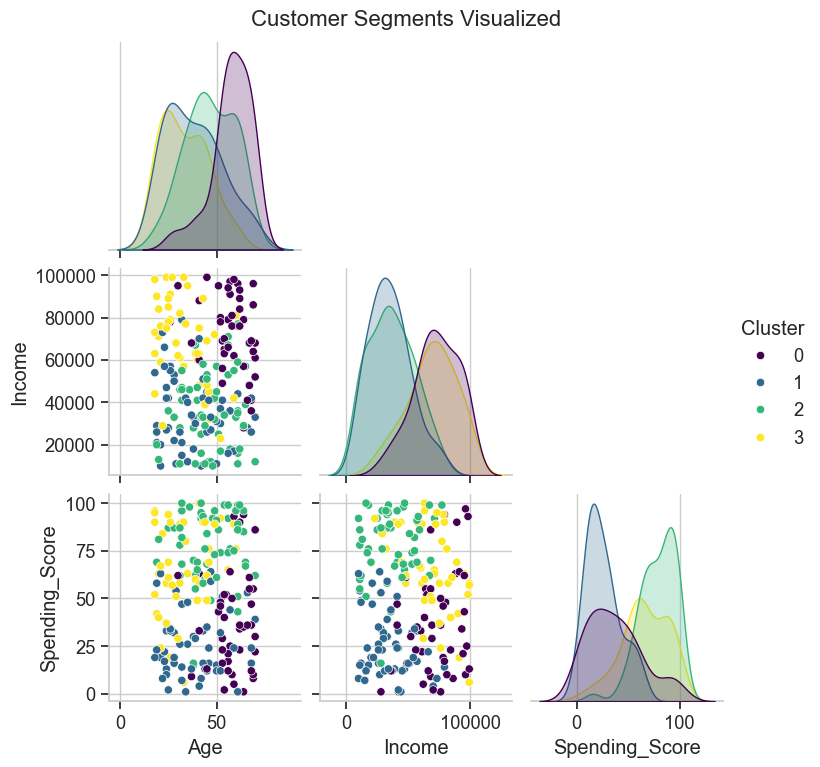

In [12]:
# Analyze clusters
cluster_analysis = customer_data.groupby('Cluster').mean()

# Display cluster characteristics
print("Cluster Profiles:")
print(cluster_analysis)

# Visualize cluster profiles with radar chart
def radar_chart(df, title):
    # Number of variables
    categories = list(df.index)
    N = len(categories)
    
    # What will be the angle of each axis in the plot
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize the figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks(color="grey", size=10)
    plt.ylim(0, 1)
    
    # Plot each cluster
    for i in range(len(df.columns)):
        values = df[df.columns[i]].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {df.columns[i]}")
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(title, size=20, y=1.1)
    
    plt.show()

# Prepare data for radar chart - normalize the values
radar_df = cluster_analysis.copy()
for column in radar_df.columns:
    radar_df[column] = (radar_df[column] - radar_df[column].min()) / (radar_df[column].max() - radar_df[column].min())

# Transpose for radar chart
radar_df = radar_df.T

# Create radar chart
radar_chart(radar_df, "Customer Segments Comparison")

# Create pair plots for selected features
plt.figure(figsize=(15, 10))
sns.pairplot(customer_data, hue='Cluster', palette='viridis',
             vars=['Age', 'Income', 'Spending_Score'], corner=True)
plt.suptitle('Customer Segments Visualized', y=1.02, fontsize=16)
plt.show()

### Customer Segment Interpretation

Based on the cluster analysis, we can interpret the customer segments as follows:

1. **Cluster 0**: Young customers with moderate income and high spending scores
2. **Cluster 1**: Older customers with high income but moderate spending
3. **Cluster 2**: Middle-aged customers with low income and low spending
4. **Cluster 3**: High-income customers with high spending and many purchases

These segments can help the business tailor their marketing strategies and customer engagement approaches to each group.

## 9. Limitations of K-means

While K-means is a powerful and widely used clustering algorithm, it has several limitations that are important to understand:

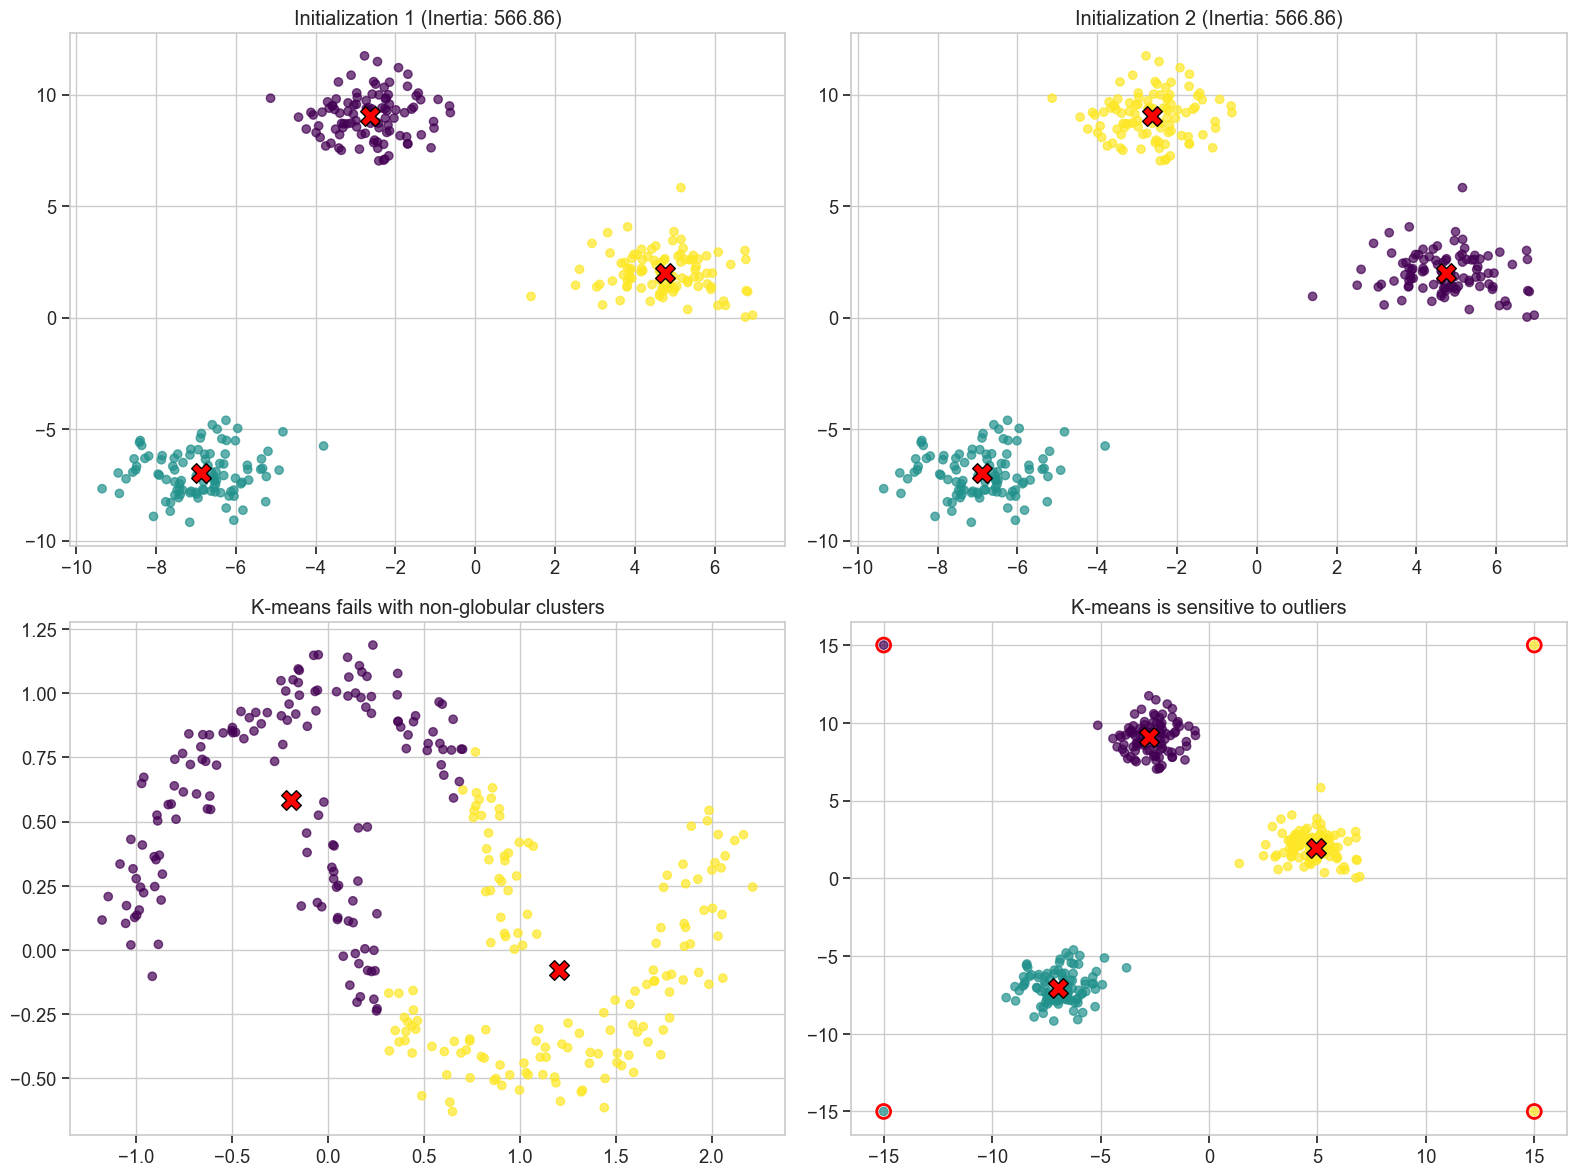

In [13]:
# Create visualizations to demonstrate K-means limitations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sensitivity to initialization
np.random.seed(42)
X_blob = make_blobs(n_samples=300, centers=3, random_state=42)[0]

# Different initializations
kmeans1 = KMeans(n_clusters=3, random_state=0, n_init=1).fit(X_blob)
kmeans2 = KMeans(n_clusters=3, random_state=50, n_init=1).fit(X_blob)

axes[0, 0].scatter(X_blob[:, 0], X_blob[:, 1], c=kmeans1.labels_, cmap='viridis', alpha=0.7)
axes[0, 0].scatter(kmeans1.cluster_centers_[:, 0], kmeans1.cluster_centers_[:, 1], 
                   marker='X', s=200, c='red', edgecolor='black')
axes[0, 0].set_title(f'Initialization 1 (Inertia: {kmeans1.inertia_:.2f})')

axes[0, 1].scatter(X_blob[:, 0], X_blob[:, 1], c=kmeans2.labels_, cmap='viridis', alpha=0.7)
axes[0, 1].scatter(kmeans2.cluster_centers_[:, 0], kmeans2.cluster_centers_[:, 1], 
                   marker='X', s=200, c='red', edgecolor='black')
axes[0, 1].set_title(f'Initialization 2 (Inertia: {kmeans2.inertia_:.2f})')

# 2. Non-globular clusters (moons)
from sklearn.datasets import make_moons
X_moon, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

kmeans_moon = KMeans(n_clusters=2, random_state=42).fit(X_moon)
axes[1, 0].scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans_moon.labels_, cmap='viridis', alpha=0.7)
axes[1, 0].scatter(kmeans_moon.cluster_centers_[:, 0], kmeans_moon.cluster_centers_[:, 1], 
                   marker='X', s=200, c='red', edgecolor='black')
axes[1, 0].set_title('K-means fails with non-globular clusters')

# 3. Sensitivity to outliers
X_outliers = np.vstack([make_blobs(n_samples=300, centers=3, random_state=42)[0],
                        np.array([[15, 15], [-15, -15], [15, -15], [-15, 15]])])

kmeans_outliers = KMeans(n_clusters=3, random_state=42).fit(X_outliers)
axes[1, 1].scatter(X_outliers[:, 0], X_outliers[:, 1], c=kmeans_outliers.labels_, cmap='viridis', alpha=0.7)
axes[1, 1].scatter(kmeans_outliers.cluster_centers_[:, 0], kmeans_outliers.cluster_centers_[:, 1], 
                   marker='X', s=200, c='red', edgecolor='black')
axes[1, 1].set_title('K-means is sensitive to outliers')

# Highlight outliers
outliers = np.array([[15, 15], [-15, -15], [15, -15], [-15, 15]])
axes[1, 1].scatter(outliers[:, 0], outliers[:, 1], s=100, edgecolor='red', facecolor='none', linewidth=2)

plt.tight_layout()
plt.show()

### Key Limitations of K-means:

1. **Requires specifying the number of clusters (K) in advance**
   - Often we don't know the true number of clusters
   - Methods like elbow and silhouette can help but are not always conclusive

2. **Sensitive to initialization**
   - Different initial centroids can lead to different final clusters
   - Common practice is to run with multiple initializations (n_init parameter)

3. **Assumes spherical clusters of similar size and density**
   - Performs poorly on non-globular or interleaved shapes
   - Alternative: Spectral clustering or DBSCAN for complex shapes

4. **Sensitive to outliers**
   - Outliers can significantly shift cluster centroids
   - Consider using K-medoids or DBSCAN for outlier-robust clustering

5. **Curse of dimensionality**
   - In high dimensions, Euclidean distances become less meaningful
   - Solution: Dimensionality reduction or using specialized similarity metrics

## 10. Handling High-dimensional Data

K-means can struggle with high-dimensional data due to the "curse of dimensionality." Let's explore techniques for clustering high-dimensional data:

1. Dimensionality reduction with PCA before applying K-means
2. Feature selection to keep only the most informative dimensions

Silhouette score on original data: 0.812
Silhouette score after PCA: 0.931


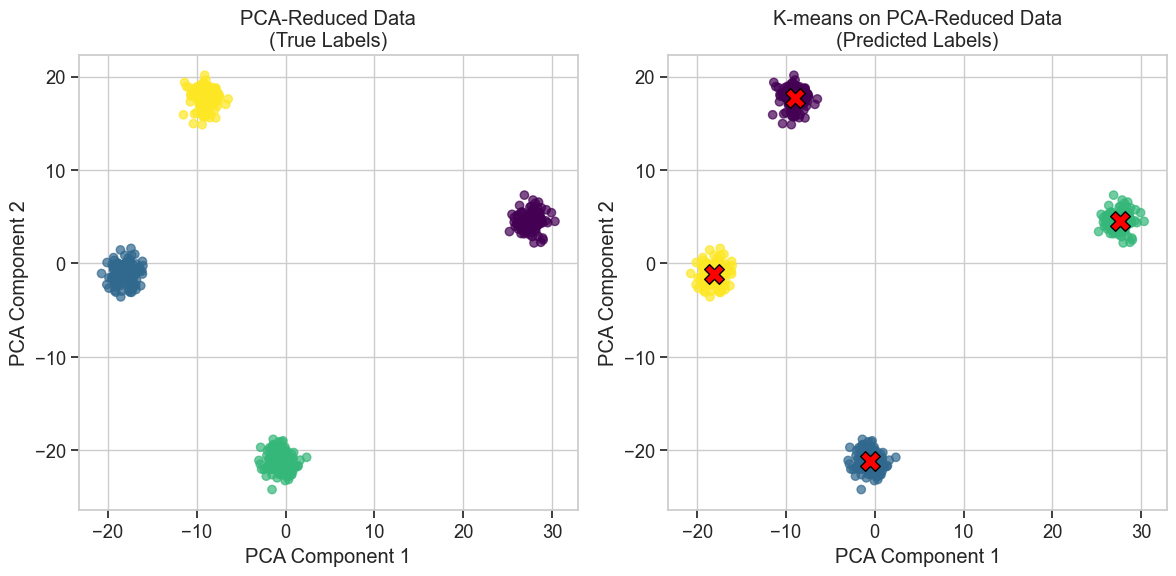

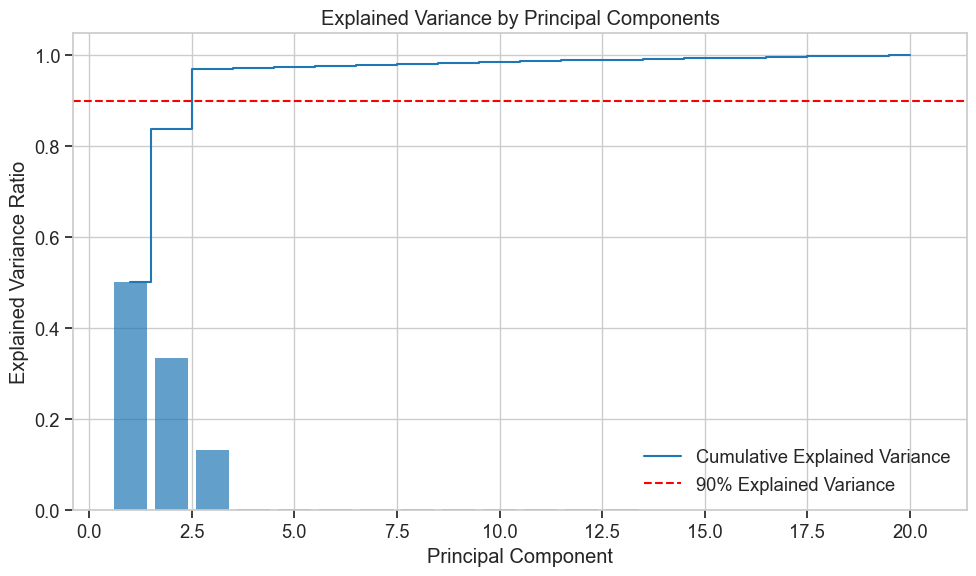

In [14]:
# Generate high-dimensional data (20 features)
X_high_dim, y_true = make_blobs(n_samples=500, centers=4, n_features=20, random_state=42)

# Apply K-means directly to high-dimensional data
kmeans_high_dim = KMeans(n_clusters=4, random_state=42)
labels_high_dim = kmeans_high_dim.fit_predict(X_high_dim)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_high_dim)

# Apply K-means to PCA-reduced data
kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

# Evaluate both approaches using silhouette score
silhouette_high_dim = silhouette_score(X_high_dim, labels_high_dim)
silhouette_pca = silhouette_score(X_pca, labels_pca)

print(f"Silhouette score on original data: {silhouette_high_dim:.3f}")
print(f"Silhouette score after PCA: {silhouette_pca:.3f}")

# Visualize PCA-reduced clusters
plt.figure(figsize=(12, 6))

# Plot the PCA-reduced data with original labels for reference
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7)
plt.title('PCA-Reduced Data\n(True Labels)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Plot the PCA-reduced data with K-means labels
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', alpha=0.7)
centers_pca = kmeans_pca.cluster_centers_
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200, c='red', edgecolor='black')
plt.title('K-means on PCA-Reduced Data\n(Predicted Labels)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

# Investigate how much variance is explained by the principal components
pca_full = PCA()
pca_full.fit(X_high_dim)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, alpha=0.7)
plt.step(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         np.cumsum(pca_full.explained_variance_ratio_), where='mid', 
         label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.title('Explained Variance by Principal Components')
plt.tight_layout()
plt.show()

### Key Insights for High-dimensional Clustering:

1. **Dimensionality reduction helps K-means perform better**
   - PCA transforms the data into a lower-dimensional space while preserving variance
   - Reduces noise and computational complexity
   
2. **Feature selection**
   - Sometimes it's better to choose specific important features rather than using PCA
   - Improves interpretability compared to abstract principal components

3. **Consider distance metrics**
   - In high dimensions, cosine similarity may work better than Euclidean distance
   - Some specialized algorithms like subspace clustering may be appropriate

4. **Validate results carefully**
   - Use silhouette score, adjusted Rand index, or other metrics to evaluate clustering quality
   - Always visualize results when possible, even if it requires dimensionality reduction

5. **Ensemble methods**
   - Consider consensus clustering or ensemble approaches for more robust results
   - Different algorithms may capture different aspects of high-dimensional structure

## Summary

In this notebook, we explored the K-means clustering algorithm in depth, including:

1. The theoretical foundations and steps of the K-means algorithm
2. Implementation from scratch and using scikit-learn
3. Methods for determining the optimal number of clusters
4. Various visualization techniques for cluster analysis
5. A real-world application in customer segmentation
6. Limitations of K-means and how to address them
7. Techniques for handling high-dimensional data

K-means is a versatile and widely-used algorithm for unsupervised learning, despite its limitations. Understanding when and how to apply it effectively is an essential skill for data scientists and machine learning practitioners.